# Task 2 - Similarity
The task is to develop a model that can find similarities in paintings (similar style/pose/face/texture)

My solution frames the problem as an image retrieval system wherein the model returns 3 images that are most similar to the query image. The model also outputs a similarity score along with the images which denotes the amount of similarity between images.



##Introduction

Inorder to build a zero shot image retrieval model that can retrieve similar paintings from a subset of the NAG Dataset (~20K images), the model was designed using a dual encoder setup for strong representations.

• CLIP and DINO were the encoders used to extract image features.
- CLIP (ViT-L/14) was used to capture the semantic meaning of the image.
- DINO (vit_large_patch14_dinov2) was used to capture the structural and spatial layout of the image.

• The embeddings created by CLIP and DINO were then normalised and fused together.

• FAISS is used as the backend engine for fast similarity search over all image embeddings. After extracting and normalizing the fused features (1792D), they are stored in a IndexFlatIP index, which computes inner product. But since all embeddings are normalized, this effectively becomes cosine similarity.

• During retrieval, the query image is converted into an embedding and searched against the index to return the top-K most similar vectors along with their similarity scores. These indices are then mapped back to the corresponding image paths to display results.

## Dataset
The NAG dataset was used here as per requirements.

The original NAG dataset contains about 130k images. Due to resource limitations of Colab, it was not possible to create embeddings for full 130k images. Hence I've downloaded a 20k subset of the dataset (even this takes about 2 hrs for embedding creation on GPU.)

No labels or annotations were used and no preprocessing beyond resizing & normalization was applied.


## Codes


Mount Google drive to upload the filtered WikiArt dataset and csv file. It also provides the checkpoints and result storage location.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Copy the dataset to colab env for faster processing.

In [4]:
!cp -r "/content/drive/MyDrive/NAG images" /content/

These are paths required for the program to run properly.

In [5]:
save_dir="/content/drive/MyDrive/Task2-Results"
index_dir="/content/drive/MyDrive/Task2-Outputs/index.faiss"
features_dir="/content/drive/MyDrive/Task2-Outputs/embeddings.npy"
images_dir="/content/drive/MyDrive/Task2-Outputs/image_paths.pkl"
query_img=""
dataset="/content/NAG images"
output_dir="/content/drive/MyDrive/Task2-Outputs"

Install missing dependencies

In [6]:
!pip install faiss-cpu timm ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-uviyrg68
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-uviyrg68
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=e30895b6d367b7e601b545f10d2f24351e18c85c02caa9a418b5a90ca5d5871f
  Stored in directory: /tmp/pip-ephem-wheel-cache-v3qoqzwb/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


### Imports

In [7]:
import numpy as np
import pickle
from tqdm import tqdm
import faiss
from PIL import Image
import os
import matplotlib.pyplot as plt
import torch
import clip
import timm
import torch.nn.functional as F
import torchvision.transforms as T
import sys

### Load CLIP and DINO



In [8]:
if torch.cuda.is_available():device='cuda'
else: device='cpu'
clip_model,clip_preprocessing=clip.load('ViT-L/14',device=device)

dino_model=timm.create_model('vit_large_patch14_dinov2', pretrained=True,num_classes=0)

dino_model.eval()
dino_model.to(device)

dino_transform = T.Compose([T.Resize(518),T.CenterCrop(518),
    T.ToTensor(),T.Normalize(mean=(0.485, 0.456, 0.406),std=(0.229, 0.224, 0.225)),])

100%|███████████████████████████████████████| 890M/890M [01:18<00:00, 11.8MiB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

### Feature Extraction

Function to load an image

In [9]:
def load_image(image_path):
    return Image.open(image_path).convert('RGB')

Function to extract and normalize CLIP features.

In [10]:
def clip_features(img):
    with torch.no_grad():
        img=clip_preprocessing(img).unsqueeze(0).to(device)
        features=clip_model.encode_image(img)
        features=F.normalize(features,dim=-1)
    return features.squeeze().cpu().numpy()

Function to extract and normalize DINO features.

In [11]:
def dino_features(img):
    with torch.no_grad():
        img=dino_transform(img).unsqueeze(0).to(device)
        features=dino_model(img)
        features=F.normalize(features,dim=-1)
    return features.squeeze().cpu().numpy()

Function to fuse CLIP and DINO embeddings.

In [12]:
def combine_features(clip_ftrs, dino_ftrs,alpha=0.5):
    clip_ftrs/=np.linalg.norm(clip_ftrs)
    dino_ftrs/=np.linalg.norm(dino_ftrs)

    combined_ftrs=np.concatenate([alpha*clip_ftrs,(1-alpha)*dino_ftrs])
    combined_ftrs/=np.linalg.norm(combined_ftrs)
    return combined_ftrs.astype('float32')

Main fn which calls above fns.

In [13]:
def extract_feature(image_path,alpha=0.5):
    img=load_image(image_path)
    clip_ftrs=clip_features(img)
    dino_ftrs=dino_features(img)
    combined_ftrs=combine_features(clip_ftrs,dino_ftrs,alpha)
    return combined_ftrs

### Generate Embeddings

Function to create embeddings for entire dataset.

In [14]:
image_paths = []
embeddings=[]

for f in tqdm(sorted(os.listdir(dataset))):
    if not  f.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):continue
    img_path=os.path.join(dataset,f)
    try:
        features=extract_feature(img_path)
        embeddings.append(features)
        image_paths.append(img_path)
    except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
embeddings=np.vstack(embeddings).astype('float32')

100%|██████████| 20013/20013 [2:09:30<00:00,  2.58it/s]


Save embeddings

In [15]:
np.save(features_dir,embeddings)

with open(images_dir,'wb') as f:
    pickle.dump(image_paths,f)

Create FAISS index

In [16]:
index=faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
faiss.write_index(index,index_dir)

### Query

Load Index and Image paths

In [17]:
index=faiss.read_index(index_dir)

with open(images_dir, "rb") as f:
    paths=pickle.load(f)

Query Setup

In [22]:
# kindly insert your image here
query_img="/content/1a2648bdf1d501d6a3e8696b13060620.jpg"
query_ftrs=extract_feature(query_img).astype("float32").reshape(1, -1)
D,I=index.search(query_ftrs, k=10)

We ignore results below a certain threshold score

In [23]:
top_score=D[0][0]

valid_results = []
for score, idx in zip(D[0], I[0]):
  print(f"Score: {score:.4f}, Path: {paths[idx]}")
  if score >= top_score * 0.75 and score>=0.54:
      valid_results.append((score,idx))

valid_results=valid_results[:3]
if len(valid_results) == 0:
  print("No valid results found.")

Score: 0.7551, Path: /content/NAG images/1fac27c1-1bde-47be-89c2-55201b944c98.jpg
Score: 0.7086, Path: /content/NAG images/b600c79d-4341-4db2-8e1d-48747f2ab72c.jpg
Score: 0.5982, Path: /content/NAG images/c0dfa573-513b-4921-aede-03f5dc7bb49a.jpg
Score: 0.5921, Path: /content/NAG images/Grapes-Bunch.jpg
Score: 0.5504, Path: /content/NAG images/f4cf8a85-49d2-4af8-aa63-9e2222328b8b.jpg
Score: 0.4656, Path: /content/NAG images/aaa0326a-4953-4db7-9121-632afe0b4f6a.jpg
Score: 0.4579, Path: /content/NAG images/d98e041f-d7b8-4dd0-9b62-35965df834af.jpg
Score: 0.4488, Path: /content/NAG images/620329b1-12df-4484-aacd-a2ef3e9a2a38.jpg
Score: 0.4469, Path: /content/NAG images/e5ca1be2-be4b-48a7-abf1-a62e74c61e82.jpg
Score: 0.4467, Path: /content/NAG images/9f9e25ba-b4a0-47dc-b825-1cc377f6a61a.jpg


Compute results

In [24]:
results=[paths[idx] for (_,idx) in valid_results]
scores=[score for (score,_) in valid_results]

View the results and store to drive

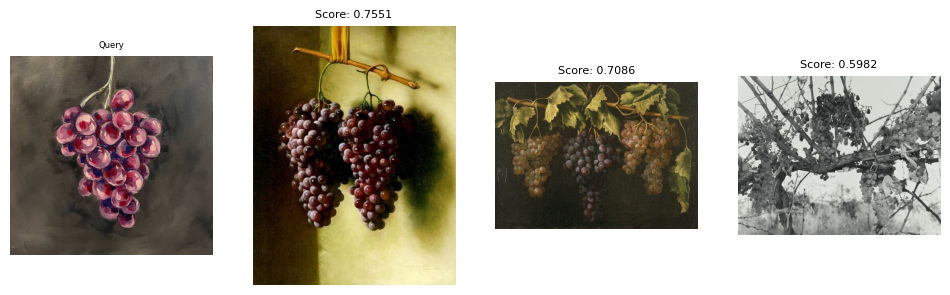

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(3*(len(results)+1), 5))

plt.subplot(1, len(results)+1, 1)
plt.imshow(Image.open(query_img))
plt.title("Query",fontsize=6)
plt.axis("off")

for i, (path, score) in enumerate(zip(results, scores)):
    plt.subplot(1, len(results)+1, i + 2)
    plt.imshow(Image.open(path))
    plt.title(f"Score: {score:.4f}", fontsize=8)
    plt.axis("off")
plt.show()

save_path = os.path.join(save_dir, "result.png")
plt.savefig(save_path, bbox_inches='tight')

### Evaluation

The evaluation methods chosen are : Recall@K, Hit@K, and MRR.

These were chosen because the model is not working with a labeled dataset. Since the dataset contains ~20K images, it is not possible to obtain all the ground truth similar images manually. Therefore, I created the ground truth by running the model on 50 different queries and then by looking at the top 5 images it returned, I registered the correct retrievals into a dictionary.

Recall@K is the main metric since it directly measures how many of the known correct matches appear within the top K results. There are many visually similar paintings that are not included in the ground truth, so using something like precision would unfairly penalize the system for returning valid but unlabeled results. Recall avoids that problem by only focusing on whether known correct matches are retrieved.

Hit@K just verifies whether at least one correct result appears in the top K.

MRR is used to understand ranking quality. It rewards cases where the correct result appears earlier in the list.

Other metrics like Precision@K, mAP, and NDCG are not suitable here. Precision depends on having complete ground truth, which is not available, so it would give misleading results. mAP and NDCG require dense relevance labels and proper ranking annotations across the dataset, which this setup does not have. Using them would not reflect the actual performance of the system.

Load Index and Image paths

In [34]:
index=faiss.read_index(index_dir)

with open(images_dir, "rb") as f:
    paths=pickle.load(f)

Import ground truth

In [35]:
sys.path.append(output_dir)
from ground_truth import ground_truth

Retrieval Function

In [36]:
def get_retrieved(query_img, k=10):
    query_ftrs=extract_feature(query_img).astype("float32").reshape(1, -1)
    D, I=index.search(query_ftrs, k=k)
    retrieved=[paths[i] for i in I[0]]
    return retrieved

Recall@K

In [37]:
def recall_at_k(retrieved, gt, k):
    retrieved_k=retrieved[:k]
    hits=sum([1 for r in retrieved_k if r in gt])
    return hits / len(gt) if len(gt) > 0 else 0

Hit@K

In [38]:
def hit_at_k(retrieved, gt, k):
    retrieved_k=retrieved[:k]
    return 1 if any(r in gt for r in retrieved_k) else 0

MRR

In [39]:
def reciprocal_rank(retrieved, gt):
    for rank, r in enumerate(retrieved, start=1):
        if r in gt:
            return 1 / rank
    return 0

Evaluation Loop

In [49]:
def get_filename(p):
    return os.path.basename(p).lower()

recall_3=[]
recall_5=[]

hit_5=[]

mrr=[]

#call fns
for query_img, gt_list in tqdm(ground_truth.items()):
    gt_list = [get_filename(p) for p in gt_list]
    retrieved=get_retrieved(query_img, k=10)
    retrieved = [get_filename(p) for p in retrieved]
    recall_3.append(recall_at_k(retrieved, gt_list, 3))
    recall_5.append(recall_at_k(retrieved, gt_list, 5))
    hit_5.append(hit_at_k(retrieved, gt_list, 5))
    mrr.append(reciprocal_rank(retrieved, gt_list))

100%|██████████| 60/60 [00:25<00:00,  2.38it/s]


Print the results

In [50]:
print(f"Recall@3: {np.mean(recall_3):.4f}")
print(f"Recall@5: {np.mean(recall_5):.4f}")
print(f"Hit@5: {np.mean(hit_5):.4f}")
print(f"MRR: {np.mean(mrr):.4f}")

Recall@3: 0.4889
Recall@5: 0.8806
Hit@5: 1.0000
MRR: 0.4903


## Conclusion

| Recall@3 | Recall@5 | Hit@5 | MRR |
|----------|----------|-------|-----|
| 0.4889 | 0.8806 | 1.0 | 0.4903|



A zero shot image retrieval model was succesfully developed successfully and the developed model showcases decent perfomance.

 The Recall@5 value is strong (around 0.88), and Hit@5 is 1.0, which means that for every query, at least one relevant image is being retrieved within the top five results.

At the same time, the ranking is not ideal. The MRR is around 0.49, which indicates that the correct match is usually not the first result, but somewhere around the second or third position. This means the system is good at finding relevant images, but not as good at ordering them correctly. In practice, this is noticeable because the best match is often present, just not at the top.

The addition of thresholding helped because without it, the system would always return something, even if the match was poor. Now it is able to filter out clearly irrelevant results, which makes the output more reliable.

The project can be improved further by integrating ArcFace (for face detection) and MediaPipe (for pose detection) but that would require dynamic fusion of CLIP, DINO, ArcFace and MediaPipe embeddings, which requires a lot of fine-tuning. I have refrained from doing so due to GPU usage limitations.